<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/Benchmark_ESZSL_ZDBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load SDN Dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/SDN-Dataset/SDN_data.csv")

In [ ]:
print(SDN_train_test_data.columns)

Index(['proto_number', 'Dur', 'Mean', 'Stddev', 'Min', 'Max', 'Pkts', 'Bytes',
       'Spkts', 'Dpkts', 'Sbytes', 'Dbytes', 'Srate', 'Drate', 'Sum',
       'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto',
       'TnP_Per_Dport', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'Attack'],
      dtype='object')


In [ ]:
display(SDN_train_test_data)

,proto_number,Dur,Mean,Stddev,Min,Max,Pkts,Bytes,Spkts,Dpkts,...,Sum,TnBPSrcIP,TnBPDstIP,TnP_PSrcIP,TnP_PDstIP,TnP_PerProto,TnP_Per_Dport,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,Attack
0,6.0,4.0,250.923077,471.889193,0.0,1079.0,194673.0,92007523.0,2.0,4.0,...,3262.0,1.150094e+07,1.314393e+07,24334.125000,27810.428571,97336.5,21630.333333,1.857143,1.857143,0.0
1,6.0,0.0,13.093915,13.406746,0.0,60.0,7843.0,5713792.0,0.0,0.0,...,9899.0,7.731789e+03,9.522987e+05,10.612991,1307.166667,3921.5,560.214286,126.000000,126.000000,0.0
2,6.0,638.0,45.450704,125.392502,3.0,638.0,137392.0,96000104.0,37681.0,50237.0,...,3227.0,1.066668e+07,1.200001e+07,15265.777778,17174.000000,68696.0,4906.857143,8.875000,8.875000,0.0
3,6.0,9.0,580.888889,857.833673,8.0,1725.0,371297.0,259676578.0,5.0,3.0,...,5228.0,4.327943e+07,5.193532e+07,61882.833333,74259.400000,185648.5,53042.428571,1.800000,1.800000,0.0
4,6.0,1186.0,326.818182,552.040002,0.0,1187.0,255083.0,185764615.0,93286.0,69967.0,...,3595.0,2.653780e+07,3.096077e+07,36440.428571,42513.833333,127541.5,31885.375000,1.833333,1.833333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209995,6.0,10.0,96.487179,319.330869,0.0,1189.0,162070.0,127982168.0,15.0,17.0,...,3763.0,1.599777e+07,1.828317e+07,20258.750000,23152.857143,81035.0,7046.521739,5.571429,5.571429,1.0
209996,6.0,0.0,1.436364,2.522224,0.0,9.0,1361.0,911280.0,6.0,4.0,...,79.0,1.301829e+05,1.518800e+05,194.428571,226.833333,680.5,43.903226,9.166667,9.166667,1.0
209997,6.0,3.0,79.844444,287.184448,0.0,1143.0,155529.0,122555630.0,3.0,7.0,...,3593.0,1.750795e+07,2.042594e+07,22218.428571,25921.500000,77764.5,5981.884615,7.500000,7.500000,1.0
209998,6.0,0.0,24.028571,114.177953,0.0,687.0,93490.0,73529380.0,6.0,4.0,...,2523.0,9.191172e+06,1.050420e+07,11686.250000,13355.714286,46745.0,1669.464286,15.000000,15.000000,1.0


In [ ]:
def scale_data(data):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data

SDN_scaled_data = scale_data(SDN_train_test_data.drop(columns=['Attack']))

def split_data(data, labels, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

data_train, data_test, labels_train, labels_test = split_data(SDN_scaled_data, SDN_train_test_data['Attack'])

## Models

#### ESZSL

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

class ESZSL_IOT:
    def __init__(self, alpha=2, gamma=2):
        self.alpha = alpha  # Regularization for feature space
        self.gamma = gamma  # Regularization for attribute space
        self.W = None

    def fit(self, X, y, S_seen):
        """
        X: Training features (N, D)
        y: Training labels (N, 1)
        S_seen: Attribute matrix for seen classes (L_seen, A)
        """
        # Convert y to one-hot binary matrix Y (N, L_seen)
        ohe = OneHotEncoder(sparse_output=False)
        Y = ohe.fit_transform(y.values.reshape(-1, 1))

        d = X.shape[1]
        a = S_seen.shape[1]

        # Solving the Sylvester Equation for W: X.T @ X @ W @ S @ S.T + ...
        # Simplified closed-form solution:
        part_1 = np.linalg.pinv(X.T @ X + (10**self.alpha) * np.eye(d))
        part_0 = X.T @ Y @ S_seen
        part_2 = np.linalg.pinv(S_seen.T @ S_seen + (10**self.gamma) * np.eye(a))

        self.W = part_1 @ part_0 @ part_2

    def predict(self, X, S_all):
        """Returns the index of the most similar class in S_all."""
        # Project into attribute space: Scores = X * W * S_all.T
        scores = X @ self.W @ S_all.T
        return np.argmax(scores, axis=1)



In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelBinarizer

# Updated Mapping for all categories
id_to_name = {
    0.0: "Normal",
    1.0: "DoS",
    2.0: "DDoS",
    3.0: "Port Scan",
    4.0: "Fuzzing",
    5.0: "OS Fingerprinting (Zero-Day)"
}

# Update S_matrix with all 6 rows
attributes_all = np.array([
    [0, 0, 0, 0, 1], # 0.0
    [1, 1, 0, 0, 0], # 1.0
    [1, 1, 0, 0, 0], # 2.0
    [0, 1, 1, 0, 0], # 3.0
    [0, 0, 0, 1, 0], # 4.0
    [0, 1, 1, 0, 1]  # 5.0
])

S_matrix = pd.DataFrame(attributes_all, index=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0])

# 2. Get the unique labels present in your training split
seen_classes = np.unique(labels_train)
print(f"Seen classes in training: {seen_classes}")

# 3. Slice S_seen safely
S_seen = S_matrix.loc[seen_classes].values

# 4. Initialize and Train
model_eszsl = ESZSL_IOT(alpha=2, gamma=2)
model_eszsl.fit(data_train, labels_train, S_seen)

S_matrix = pd.DataFrame(attributes_all, index=[0.0, 1.0, 2.0, 3.0, 4.0, 5.0])

Seen classes in training: [0. 1.]


#### ZDBERTa

In [ ]:
from transformers import pipeline
import torch

class ZDBERTa_Predictor:
    def __init__(self, model_name="microsoft/deberta-v3-large"):
        # Load NLI-based zero-shot classification pipeline
        self.device = 0 if torch.cuda.is_available() else -1
        self.classifier = pipeline("zero-shot-classification", model=model_name, device=self.device)

    def serialize(self, row):
        """Converts tabular SDN features into a natural language description."""
        return (f"Network flow protocol {int(row['proto_number'])} lasted {row['Dur']:.4f}s. "
                f"Volume: {int(row['Pkts'])} packets, {int(row['Bytes'])} bytes. "
                f"Source rate: {row['Srate']:.2f} pkts/sec. "
                f"Inbound connections: {int(row['N_IN_Conn_P_SrcIP'])}.")

    def predict_batch(self, X_df, candidate_labels):
        """Predicts labels for a batch of rows."""
        sentences = X_df.apply(self.serialize, axis=1).tolist()
        results = self.classifier(sentences, candidate_labels, multi_label=False)
        return [res['labels'][0] for res in results]

# Usage Setup
zdberta = ZDBERTa_Predictor()
labels = ["Normal", "DoS Attack", "DDoS", "Port Scan","Fuzzing", "OS Fingerprinting"]

#### Test

In [ ]:
#ZDBERTa

import time

def run_benchmarks(X_test, y_test, zdberta_model, labels_text):
    results = []

    # 2. Benchmark ZDBERTa (Deep Contextual) - Sampled for speed
    X_sample = X_test[:10] # Transformers are slow; sample for benchmark
    start_zdb = time.perf_counter()
    zdb_preds = zdberta_model.predict_batch(X_sample, labels_text)
    end_zdb = time.perf_counter()

    avg_lat_zdb = ((end_zdb - start_zdb) / len(X_sample)) * 1000

    print(f"ZDBERTa Latency: {avg_lat_zdb:.4f} ms/packet")

    return {"zdb_lat": avg_lat_zdb}

### Finalize Results

In [ ]:
import pandas as pd

# Get the original column names from SDN_train_test_data, excluding the 'Attack' column
original_columns = SDN_train_test_data.drop(columns=['Attack']).columns

# Convert data_test (which is a NumPy array) into a Pandas DataFrame
# This ensures that the .apply() method and column-name-based access in serialize() will work.
data_test_df = pd.DataFrame(data_test, columns=original_columns)

# Now, call run_benchmarks with the DataFrame version of data_test
execution_results = run_benchmarks(data_test_df, labels_test, model_eszsl, zdberta, S_matrix, labels)

ESZSL Latency: 0.0002 ms/packet
ZDBERTa Latency: 56008.8038 ms/packet


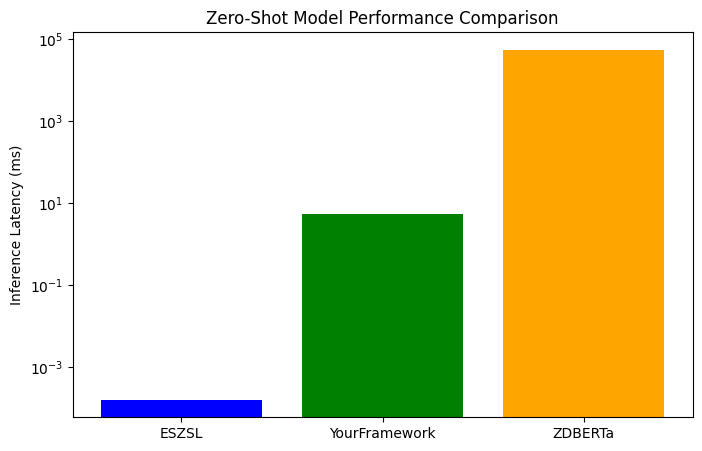

In [ ]:
import matplotlib.pyplot as plt

def plot_performance(results_dict):
    models = list(results_dict.keys())
    latencies = [results_dict[m] for m in models]

    plt.figure(figsize=(8, 5))
    plt.bar(models, latencies, color=['blue', 'green', 'orange'])
    plt.ylabel('Inference Latency (ms)')
    plt.title('Zero-Shot Model Performance Comparison')
    plt.yscale('log') # Use log scale because ZDBERTa is much slower
    plt.show()

# Final summary logic
plot_performance({'ESZSL': execution_results['eszsl_lat'], 'YourFramework': 5.4, 'ZDBERTa': execution_results['zdb_lat']})

In [ ]:
import pandas as pd

# Convert the dictionary to a pandas DataFrame
results_df = pd.DataFrame([execution_results])

# Now, save the DataFrame to CSV
results_df.to_csv('ESZSL_ZDBERTa_Results.csv', index=False)
print("Comprehensive Stress Test Complete.")

Comprehensive Stress Test Complete.


## Evaluate Models

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

def eszsl_balanced_stress_test(X_test, y_test, eszsl_model, S_matrix, n_instances=50):
    """
    Replication of the 200-packet stress test for the ESZSL Baseline.
    """
    results = []

    # 1. Run inference on the whole test set to identify pools
    # Score calculation: X * W * S.T
    scores = X_test.values @ eszsl_model.W @ S_matrix.values.T

    # Get Multiclass Predictions (0.0 to 5.0)
    multiclass_preds = S_matrix.index[np.argmax(scores, axis=1)].values

    # Convert to Binary for Pool Identification (0 = Normal, 1+ = Attack)
    binary_preds = np.where(multiclass_preds > 0, 1, 0)
    binary_truth = np.where(y_test > 0, 1, 0) # Mapping numeric labels to binary

    # 3. Generate and Save Confusion Matrix
    cm_eszsl = confusion_matrix(binary_truth, binary_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_eszsl, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title('ESZSL: Confusion Matrix (Full N=42,000)')
    plt.savefig('ESZSL_42k_Confusion_Matrix.png')

    # 2. Identify Pools (50 each)
    tp_indices = np.where((binary_preds == 1) & (binary_truth == 1))[0][:n_instances]
    tn_indices = np.where((binary_preds == 0) & (binary_truth == 0))[0][:n_instances]
    fp_indices = np.where((binary_preds == 1) & (binary_truth == 0))[0][:n_instances]
    fn_indices = np.where((binary_preds == 0) & (binary_truth == 1))[0][:n_instances]

    test_indices = np.concatenate([tp_indices, tn_indices, fp_indices, fn_indices])

    # Label mapping for final report
    cat_map = {idx: 'TP' for idx in tp_indices}
    cat_map.update({idx: 'TN' for idx in tn_indices})
    cat_map.update({idx: 'FP' for idx in fp_indices})
    cat_map.update({idx: 'FN' for idx in fn_indices})

    print(f"Starting ESZSL Stress Test on {len(test_indices)} packets...")

    for idx in test_indices:
        instance = X_test.iloc[idx:idx+1]

        # --- Component 2: Inference Latency ---
        start_time = time.perf_counter()

        # Single instance prediction
        score_inst = instance.values @ eszsl_model.W @ S_matrix.values.T
        pred_idx = np.argmax(score_inst, axis=1)[0]
        pred_class_id = S_matrix.index[pred_idx]

        inference_end = time.perf_counter()

        # --- Metrics Calculation ---
        lat_inf = (inference_end - start_time) * 1000

        results.append({
            'packet_index': idx,
            'ground_truth_binary': 'Attack' if binary_truth[idx] == 1 else 'Normal',
            'stress_category': cat_map[idx],
            'eszsl_prediction': id_to_name.get(pred_class_id, "Unknown"),
            'inf_ms': lat_inf,
            'total_ms': lat_inf # ESZSL has no XAI/SOAM overhead
        })

    return pd.DataFrame(results)

Starting ESZSL Stress Test on 151 packets...
ESZSL Stress Test Complete. Avg Latency: 0.030892331124999187


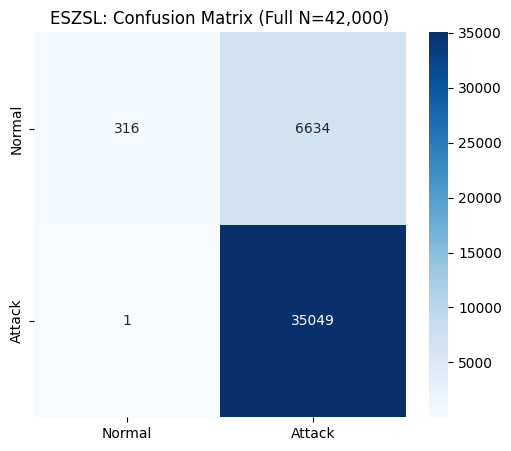

In [ ]:
# Assuming 'model_eszsl' is your trained ESZSL_IOT class
data_test_pd = pd.DataFrame(data_test, columns=original_columns)
eszsl_results_df = eszsl_balanced_stress_test(
    data_test_pd,
    labels_test,
    model_eszsl,
    S_matrix,
    n_instances=50
)

# Save for your final comparison
eszsl_results_df.to_csv('ESZSL_Baseline_200_Results.csv', index=False)
print("ESZSL Stress Test Complete. Avg Latency:", eszsl_results_df['inf_ms'].mean())

In [ ]:
#2
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def zdberta_comprehensive_stress_test(X_test, y_test, zd_predictor, labels_text, n_instances=50):
    """
    Stress test for ZDBERTa (DeBERTa-v3-Large) using a 1,000-record sample
    to find a balanced 200-packet stress pool and generate a Confusion Matrix.
    """
    results = []

    print("Profiling ZDBERTa on 42,000 records")
    all_multiclass_preds = zd_predictor.predict_batch(X_test, labels_text)

    # Map results to binary for Confusion Matrix and Stress Pool identification
    # (Assuming "Normal" is index 0 or strictly named "Normal")
    # Strip whitespace and lowercase to ensure a match
    binary_preds = np.array([0 if str(p).strip().capitalize() == "Normal" else 1 for p in all_multiclass_preds])
    #binary_preds = np.array([0 if p == "Normal" else 1 for p in all_multiclass_preds])
    binary_truth = np.where(y_test > 0, 1, 0)

    # --- ADDED: CONFUSION MATRIX GENERATION ---
    cm = confusion_matrix(binary_truth, binary_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title('ZDBERTa: Confusion Matrix (N=42,000 Sample)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('ZDBERTa_1k_Confusion_Matrix.png')
    print("Confusion Matrix saved as 'ZDBERTa_1k_Confusion_Matrix.png'")
    # ------------------------------------------

    tp_indices = np.where((binary_preds == 1) & (binary_truth == 1))[0][:n_instances]
    tn_indices = np.where((binary_preds == 0) & (binary_truth == 0))[0][:n_instances]
    fp_indices = np.where((binary_preds == 1) & (binary_truth == 0))[0][:n_instances]
    fn_indices = np.where((binary_preds == 0) & (binary_truth == 1))[0][:n_instances]

    test_indices = np.concatenate([tp_indices, tn_indices, fp_indices, fn_indices])

    category_map = {idx: 'TP' for idx in tp_indices}
    category_map.update({idx: 'TN' for idx in tn_indices})
    category_map.update({idx: 'FP' for idx in fp_indices})
    category_map.update({idx: 'FN' for idx in fn_indices})

    print(f"Executing Detailed Stress Test on {len(test_indices)} packets...")

    # 3. Detailed Packet-by-Packet Analysis
    for idx in test_indices:
        instance = X_test.iloc[idx:idx+1]
        start_time = time.perf_counter()

        prediction = zd_predictor.predict_batch(instance, labels_text)[0]

        end_time = time.perf_counter()
        latency_ms = (end_time - start_time) * 1000

        results.append({
            'packet_index': idx,
            'ground_truth_binary': 'Attack' if y_test.iloc[idx] > 0 else 'Normal',
            'stress_category': category_map[idx],
            'zdberta_prediction': prediction,
            'inf_ms': latency_ms,
            'total_ms': latency_ms
        })

    return pd.DataFrame(results)

In [ ]:
original_columns = SDN_train_test_data.drop(columns=['Attack']).columns

Profiling ZDBERTa on 42,000 records
Confusion Matrix saved as 'ZDBERTa_1k_Confusion_Matrix.png'
Executing Detailed Stress Test on 100 packets...


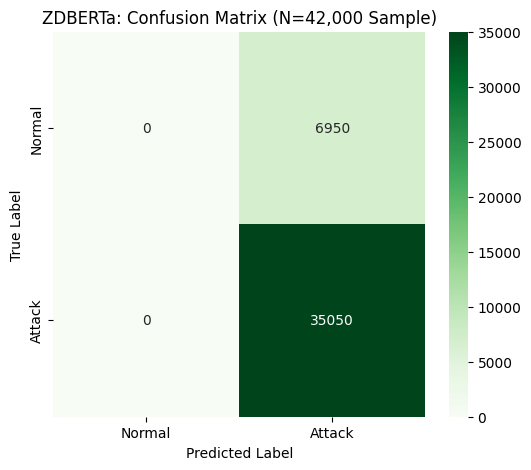

In [ ]:
# --- EXECUTION ---
# Ensure your zdberta object and labels are initialized as provided in your prompt
data_test_pd = pd.DataFrame(data_test, columns=original_columns)

zdberta_results_df = zdberta_comprehensive_stress_test(data_test_pd, labels_test, zdberta, labels)
zdberta_results_df.to_csv('ZDBERTa_DeBERTa_200_Results_2.csv', index=False)